In [1]:
import torch
print(torch.__version__)
print("torch available",torch.cuda.is_available())

2.10.0+cu128
torch available True


In [2]:
import torchvision
import torchvision.transforms as transforms

# Transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)

# Download and load test data
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training images:", len(trainset))
print("Test images:", len(testset))

100%|██████████| 170M/170M [00:03<00:00, 49.3MB/s]


Training images: 50000
Test images: 10000


In [3]:
from torch.utils.data import DataLoader

trainloader=DataLoader(trainset,batch_size=32,shuffle=True)
testloader=DataLoader(testset,batch_size=32,shuffle=True)

print("Number of training batches:",len(trainloader))
print("Number of test batches:", len(testloader))

Number of training batches: 1563
Number of test batches: 313


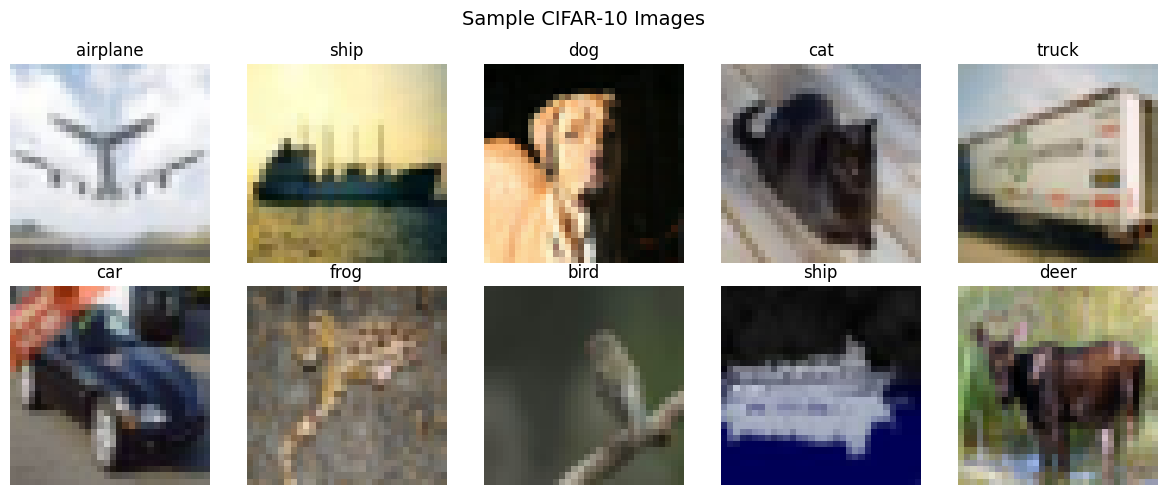

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Class names
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Get one batch of images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i]
    img = img / 2 + 0.5  # unnormalize back to 0-1
    img = img.numpy().transpose((1, 2, 0))  # convert to HWC format for matplotlib
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Conv layer 1
        x = self.pool(F.relu(self.conv1(x)))
        # Conv layer 2
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(-1, 64 * 8 * 8)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [10]:
import torch.optim as optim

#Move model to GPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

#Loss function
criterion=nn.CrossEntropyLoss()

#Optimizer
optimizer=optim.Adam(model.parameters(),lr=0.001)
print("Training On:", device)
print("Model Ready!")

Training On: cuda
Model Ready!


In [11]:
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(trainloader):.3f} - Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch 1/10 - Loss: 1.304 - Accuracy: 53.01%
Epoch 2/10 - Loss: 0.908 - Accuracy: 67.91%
Epoch 3/10 - Loss: 0.705 - Accuracy: 75.00%
Epoch 4/10 - Loss: 0.539 - Accuracy: 81.03%
Epoch 5/10 - Loss: 0.378 - Accuracy: 86.67%
Epoch 6/10 - Loss: 0.254 - Accuracy: 91.05%
Epoch 7/10 - Loss: 0.168 - Accuracy: 94.23%
Epoch 8/10 - Loss: 0.123 - Accuracy: 95.80%
Epoch 9/10 - Loss: 0.098 - Accuracy: 96.69%
Epoch 10/10 - Loss: 0.092 - Accuracy: 96.89%
Training Complete!


In [12]:
correct = 0
total = 0

model.eval()  # switch to evaluation mode

with torch.no_grad():  # don't calculate gradients
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.05%
